# Compare training experiments

This notebook is a read-only view over runs saved in `artifacts/experiments`. It compares headline prediction and betting metrics, shows exactly which configurations differ, and inspects threshold, Optuna, feature-schema, and residual behavior.

> A ranking is only an apples-to-apples comparison when the runs use the same holdout dates and games. The cohort check below makes differences visible before plotting results.

In [ ]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "pyproject.toml").exists():
    raise RuntimeError("Could not find the project root containing pyproject.toml.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from training_pipeline import build_leaderboard

EXPERIMENT_ROOT = PROJECT_ROOT / "artifacts" / "experiments"
TARGET_FAMILY = "line_error"
COMPARISON_GROUP = "temp_csv_comparison"
KEEP_LATEST_PER_KEY = True  # False shows repeated executions of the same setup.

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
plt.style.use("seaborn-v0_8-whitegrid")


# --- shared helpers (defined here so every later section can use them) ------

def read_json(path: Path) -> dict:
    return json.loads(Path(path).read_text())


def flatten_mapping(value: dict, prefix: str = "") -> dict[str, object]:
    flattened = {}
    for key, item in value.items():
        full_key = f"{prefix}.{key}" if prefix else key
        if isinstance(item, dict):
            flattened.update(flatten_mapping(item, full_key))
        else:
            flattened[full_key] = item
    return flattened


def display_value(value: object) -> object:
    if isinstance(value, (dict, list, tuple)):
        return json.dumps(value, sort_keys=True)
    return value


print("Project root:", PROJECT_ROOT)
print("Experiment root:", EXPERIMENT_ROOT)

## 1. Discover and select runs

Runs are filtered by `TARGET_FAMILY` and `COMPARISON_GROUP`. When `KEEP_LATEST_PER_KEY` is enabled, only the newest execution for each data version/configuration is retained for the main plots.

In [2]:
leaderboard = build_leaderboard(EXPERIMENT_ROOT, target_family=TARGET_FAMILY)
if leaderboard.empty:
    raise ValueError(f"No {TARGET_FAMILY!r} runs found under {EXPERIMENT_ROOT}.")

comparison = leaderboard.loc[
    leaderboard["comparison_group"] == COMPARISON_GROUP
].copy()
if comparison.empty:
    available = sorted(leaderboard["comparison_group"].dropna().unique().tolist())
    raise ValueError(
        f"No runs found for comparison_group={COMPARISON_GROUP!r}. "
        f"Available groups: {available}"
    )

comparison["created_at"] = pd.to_datetime(comparison["created_at"], errors="coerce")
comparison["comparison_key"] = (
    comparison["data_version"]
    .fillna(comparison["training_version"])
    .fillna(comparison["config_fingerprint"])
    .fillna(comparison["run_name"])
)

all_group_runs = comparison.sort_values("created_at").reset_index(drop=True)
if KEEP_LATEST_PER_KEY:
    selected_runs = (
        all_group_runs.groupby("comparison_key", dropna=False, as_index=False)
        .tail(1)
        .sort_values("comparison_key")
        .reset_index(drop=True)
    )
else:
    selected_runs = all_group_runs.copy()

run_columns = [
    "run_name", "experiment_id", "comparison_key", "data_version",
    "training_version", "created_at", "holdout_start", "holdout_end",
    "holdout_n_games", "config_fingerprint",
]
display(all_group_runs[[c for c in run_columns if c in all_group_runs.columns]])
display(Markdown(f"**Selected {len(selected_runs)} run(s) for the main comparison.**"))

,run_name,experiment_id,comparison_key,data_version,training_version,created_at,holdout_start,holdout_end,holdout_n_games,config_fingerprint
0,temp_20260801_175710,a723e78eef1a,20260704-old-3240col,20260704-old-3240col,temp-dataset-comparison,2026-08-01 17:57:10.979553+00:00,2026-03-08T00:00:00,2026-04-17T00:00:00,287,1df4ee694c05
1,temp_20260801_175726,232a03e74258,20260110-train-2-0-2145col,20260110-train-2-0-2145col,temp-dataset-comparison,2026-08-01 17:57:26.301173+00:00,2025-12-03T00:00:00,2026-01-10T00:00:00,258,cec2f8a7289f
2,temp_20260801_181029,c33bad92ec7c,20260110-train-2-0-2145col,20260110-train-2-0-2145col,temp-dataset-comparison,2026-08-01 18:10:29.477943+00:00,2025-12-03T00:00:00,2026-01-10T00:00:00,258,9edef5198bd2


**Selected 2 run(s) for the main comparison.**

## 2. Verify the evaluation cohort

MAE, win rate, and ROI can only be compared directly when they were measured over the same evaluation cohort. This check is deliberately prominent.

In [3]:
cohort_columns = [
    "holdout_start", "holdout_end", "holdout_n_games", "n_candidates"
]
cohorts = selected_runs[[c for c in cohort_columns if c in selected_runs.columns]].drop_duplicates()
display(cohorts)

cohorts_are_comparable = len(cohorts) == 1
if cohorts_are_comparable:
    display(Markdown("✅ **The selected runs report the same holdout boundaries and size.**"))
else:
    display(Markdown(
        "⚠️ **The selected runs use different holdout cohorts.** The charts remain useful "
        "for describing each run, but they do not isolate the effect of the changed dataset or configuration."
    ))

,holdout_start,holdout_end,holdout_n_games,n_candidates
0,2025-12-03T00:00:00,2026-01-10T00:00:00,258,258
1,2026-03-08T00:00:00,2026-04-17T00:00:00,287,287


⚠️ **The selected runs use different holdout cohorts.** The charts remain useful for describing each run, but they do not isolate the effect of the changed dataset or configuration.

## 3. Headline metrics

Two distinct questions, kept separate on purpose:

- **Cross-validation** (`cv_*`) — how the configuration behaved across the walk-forward folds *inside the development period*. This is what Optuna optimised, and it is the more stable signal because it averages many folds.
- **Test set** (`final_test_*`, `roi`) — a single held-out period the model never saw. Fewer games, so noisier, but it is the honest estimate.

Both are compared against the same reference: **trusting the bookmaker's closing line**. `bias_baseline_*` is the harder null — the line plus its historical drift — because a model that only rediscovers a league-wide over/under tendency will beat the raw line but not this one.

Read ROI together with bet volume and its win-rate confidence interval. A high ROI on very few bets is not evidence.

In [ ]:
def _pct_frame(df: pd.DataFrame, percent_columns, float_columns=()):
    """Style a table: percentages as %, everything else to 3 decimals."""
    formatters = {c: "{:.2%}" for c in percent_columns if c in df.columns}
    formatters.update({c: "{:.3f}" for c in float_columns if c in df.columns})
    return df.style.format(formatters, na_rep="—")


# --- cross-validation: averaged over folds, so the more stable comparison ---
cv_columns = [
    "comparison_key", "cv_mae", "baseline_cv_mae", "cv_improvement_over_baseline_pct",
    "cv_rmse", "baseline_cv_rmse", "cv_ou_acc", "n_trials", "selected_trial_number",
]
cv_summary = selected_runs.copy()
cv_summary["cv_improvement_over_baseline_pct"] = (
    cv_summary["baseline_cv_mae"] - cv_summary["cv_mae"]
) / cv_summary["baseline_cv_mae"]
cv_summary = cv_summary[[c for c in cv_columns if c in cv_summary.columns]]

display(Markdown("**Cross-validation (development folds)**"))
display(_pct_frame(
    cv_summary,
    percent_columns=["cv_improvement_over_baseline_pct", "cv_ou_acc"],
    float_columns=["cv_mae", "baseline_cv_mae", "cv_rmse", "baseline_cv_rmse"],
))

# --- held-out test period ---
test_columns = [
    "comparison_key", "holdout_start", "holdout_end", "holdout_n_games",
    "final_test_mae", "baseline_holdout_mae", "mae_improvement_over_baseline_pct",
    "bias_baseline_mae", "final_test_ou_acc",
    "bet_min_edge", "roi", "bias_baseline_roi", "roi_vs_bias_baseline",
    "profit_units", "n_bets", "bet_rate",
    "win_rate", "win_rate_ci_low", "win_rate_ci_high",
    "break_even_rate", "is_significant",
]
test_summary = selected_runs[[c for c in test_columns if c in selected_runs.columns]]

display(Markdown("**Held-out test period**"))
display(_pct_frame(
    test_summary,
    percent_columns=[
        "mae_improvement_over_baseline_pct", "final_test_ou_acc", "roi",
        "bias_baseline_roi", "roi_vs_bias_baseline", "bet_rate", "win_rate",
        "win_rate_ci_low", "win_rate_ci_high", "break_even_rate",
    ],
    float_columns=[
        "final_test_mae", "baseline_holdout_mae", "bias_baseline_mae", "profit_units",
    ],
))

# CV and test should broadly agree. When they disagree sharply, the test result
# is usually the small sample talking, not a real regime change.
if {"cv_mae", "final_test_mae"} <= set(selected_runs.columns):
    for row in selected_runs.itertuples(index=False):
        if pd.notna(row.cv_mae) and pd.notna(row.final_test_mae):
            gap = row.final_test_mae - row.cv_mae
            if abs(gap) > 1.0:
                display(Markdown(
                    f"⚠️ **{row.comparison_key}**: test MAE is {gap:+.2f} vs CV MAE "
                    f"({row.final_test_mae:.3f} vs {row.cv_mae:.3f}). A gap this size "
                    "usually reflects a different scoring environment in the holdout "
                    "period rather than a broken model — check the baseline moved too."
                ))

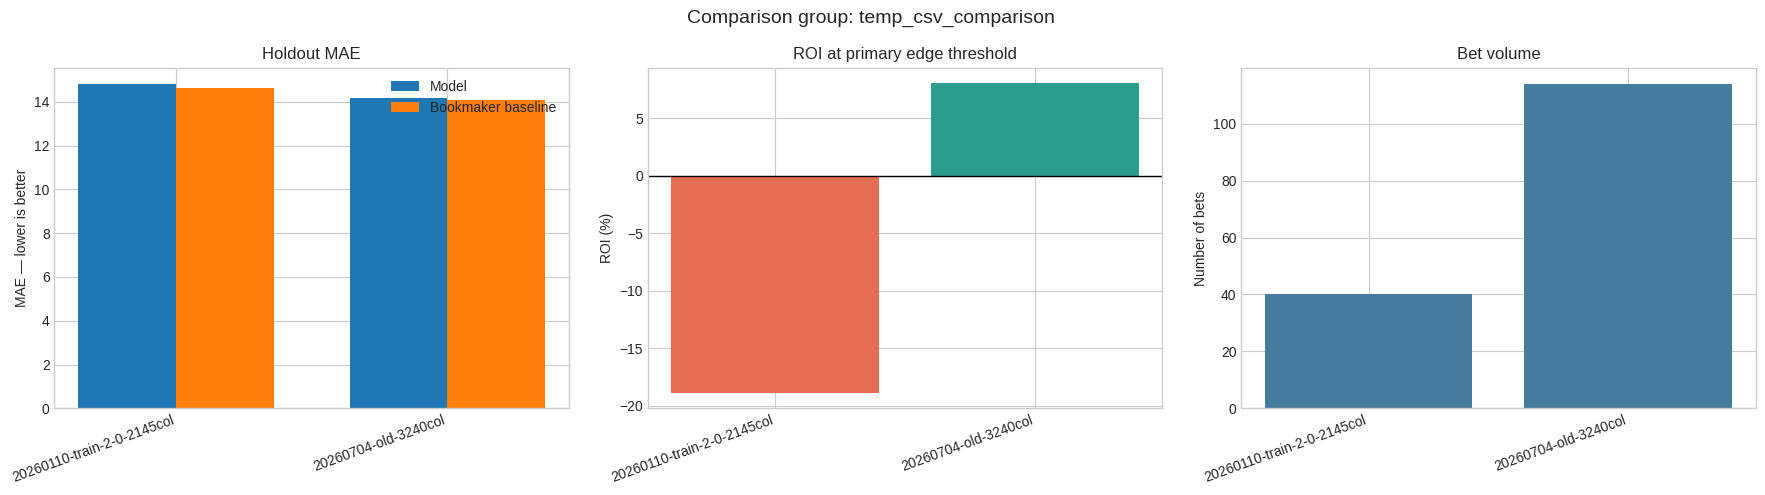

In [6]:
plot_df = selected_runs.set_index("comparison_key")
labels = plot_df.index.astype(str).tolist()
x = np.arange(len(plot_df))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
width = 0.36
axes[0].bar(x - width / 2, plot_df["final_test_mae"], width, label="Model")
axes[0].bar(x + width / 2, plot_df["baseline_holdout_mae"], width, label="Bookmaker baseline")
axes[0].set_title("Holdout MAE")
axes[0].set_ylabel("MAE — lower is better")
axes[0].legend()

roi_pct = plot_df["roi"] * 100
axes[1].bar(x, roi_pct, color=["#2a9d8f" if value >= 0 else "#e76f51" for value in roi_pct.fillna(0)])
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title(f"ROI at primary edge threshold")
axes[1].set_ylabel("ROI (%)")

axes[2].bar(x, plot_df["n_bets"], color="#457b9d")
axes[2].set_title("Bet volume")
axes[2].set_ylabel("Number of bets")

for ax in axes:
    ax.set_xticks(x, labels, rotation=20, ha="right")
fig.suptitle(f"Comparison group: {COMPARISON_GROUP}", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
for position, row in enumerate(selected_runs.itertuples(index=False)):
    if pd.isna(row.win_rate):
        continue
    low = row.win_rate - row.win_rate_ci_low
    high = row.win_rate_ci_high - row.win_rate
    ax.errorbar(
        position, row.win_rate * 100,
        yerr=np.array([[low * 100], [high * 100]]),
        fmt="o", capsize=6, markersize=8,
    )
    ax.scatter(
        position, row.break_even_rate * 100, marker="x", color="black", s=70,
        label="Break-even" if position == 0 else None,
    )
# An interval crossing this line means the edge is not distinguishable from
# noise, however attractive the point estimate looks.
ax.axhline(
    selected_runs["break_even_rate"].dropna().mean() * 100,
    color="black", linestyle=":", linewidth=1, label="Break-even rate",
)
ax.set_xticks(np.arange(len(selected_runs)), selected_runs["comparison_key"], rotation=20, ha="right")
ax.set_ylabel("Win rate (%)")
ax.set_title("Test-set win rate with 95% Wilson interval")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

## 4. Cross-validation, fold by fold

The headline `cv_mae` is a mean over folds, which hides the thing that matters most: **consistency**. A configuration that beats the line on 8 of 10 folds is a different proposition from one that averages the same number by winning three folds hugely and losing the rest.

Each run stores per-fold model metrics on its selected Optuna trial (`fold_metrics`) and the matching per-fold bookmaker-line baseline in `baseline_fold_metrics.csv`. They join on fold number, which lets us compare the model against the line *within each fold* — the paired comparison, which removes the "some folds are simply harder" confound that makes raw MAE across runs hard to read.

In [ ]:
def load_fold_comparison(run_name: str, comparison_key: str) -> pd.DataFrame | None:
    """Per-fold model metrics joined to the per-fold bookmaker-line baseline."""
    run_dir = EXPERIMENT_ROOT / run_name

    trial_path = run_dir / "optuna_selected_trial.json"
    if not trial_path.exists():
        trial_path = run_dir / "optuna_best_trial.json"
    if not trial_path.exists():
        return None  # a run that pinned fixed_params has no trial to read

    payload = read_json(trial_path)
    trial = payload.get("selected_trial") or payload.get("best_trial") or {}
    fold_metrics = (trial.get("user_attrs") or {}).get("fold_metrics")
    if not fold_metrics:
        return None

    model_folds = pd.DataFrame(fold_metrics).rename(
        columns={"mae": "model_mae", "rmse": "model_rmse", "ou_accuracy": "model_ou_acc"}
    )

    baseline_path = run_dir / "baseline_fold_metrics.csv"
    if not baseline_path.exists():
        return None
    baseline_folds = pd.read_csv(baseline_path).rename(
        columns={"mae": "baseline_mae", "rmse": "baseline_rmse"}
    )

    folds = model_folds.merge(
        baseline_folds[["fold", "n_games", "baseline_mae", "baseline_rmse"]],
        on="fold", how="inner",
    )
    folds["comparison_key"] = comparison_key
    # Positive => the model beat the line on that fold.
    folds["mae_edge_vs_line"] = folds["baseline_mae"] - folds["model_mae"]
    folds["beat_line"] = folds["mae_edge_vs_line"] > 0
    return folds


fold_frames = [
    frame
    for row in selected_runs.itertuples(index=False)
    if (frame := load_fold_comparison(row.run_name, str(row.comparison_key))) is not None
]

if not fold_frames:
    display(Markdown(
        "_No per-fold metrics available. Runs that set `optuna.fixed_params` skip "
        "tuning, so they have no Optuna trial to read folds from._"
    ))
    all_folds = pd.DataFrame()
else:
    all_folds = pd.concat(fold_frames, ignore_index=True)

    consistency = (
        all_folds.groupby("comparison_key")
        .agg(
            folds=("fold", "count"),
            folds_beating_line=("beat_line", "sum"),
            mean_mae_edge=("mae_edge_vs_line", "mean"),
            worst_fold_edge=("mae_edge_vs_line", "min"),
            best_fold_edge=("mae_edge_vs_line", "max"),
            mae_edge_std=("mae_edge_vs_line", "std"),
            mean_model_mae=("model_mae", "mean"),
            mean_baseline_mae=("baseline_mae", "mean"),
            mean_ou_acc=("model_ou_acc", "mean"),
        )
        .reset_index()
    )
    consistency["win_rate_across_folds"] = (
        consistency["folds_beating_line"] / consistency["folds"]
    )
    display(_pct_frame(
        consistency,
        percent_columns=["win_rate_across_folds", "mean_ou_acc"],
        float_columns=[
            "mean_mae_edge", "worst_fold_edge", "best_fold_edge", "mae_edge_std",
            "mean_model_mae", "mean_baseline_mae",
        ],
    ))

In [ ]:
if not all_folds.empty:
    keys = all_folds["comparison_key"].unique().tolist()
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1) Model vs line per fold. Folds differ in difficulty, so the gap between
    #    the paired lines matters, not their absolute height.
    for key in keys:
        folds = all_folds[all_folds["comparison_key"] == key].sort_values("fold")
        line, = axes[0].plot(folds["fold"], folds["model_mae"], marker="o", label=f"{key} — model")
        axes[0].plot(
            folds["fold"], folds["baseline_mae"], marker="x", linestyle="--",
            color=line.get_color(), alpha=0.65, label=f"{key} — line",
        )
    axes[0].set_title("Per-fold MAE: model vs bookmaker line")
    axes[0].set_xlabel("Fold")
    axes[0].set_ylabel("MAE — lower is better")
    axes[0].legend(fontsize=8)

    # 2) The paired difference. Above zero = the model beat the line that fold.
    width = 0.8 / max(len(keys), 1)
    for offset, key in enumerate(keys):
        folds = all_folds[all_folds["comparison_key"] == key].sort_values("fold")
        positions = folds["fold"] + (offset - (len(keys) - 1) / 2) * width
        axes[1].bar(positions, folds["mae_edge_vs_line"], width, label=key)
    axes[1].axhline(0, color="black", linewidth=1)
    axes[1].set_title("MAE edge over the line, per fold\n(above 0 = model wins)")
    axes[1].set_xlabel("Fold")
    axes[1].set_ylabel("Baseline MAE − model MAE")
    axes[1].legend(fontsize=8)

    # 3) Spread of that edge. A distribution straddling zero means the average
    #    is carried by a few folds rather than a repeatable advantage.
    axes[2].boxplot(
        [all_folds.loc[all_folds["comparison_key"] == key, "mae_edge_vs_line"] for key in keys],
        tick_labels=keys, showmeans=True,
    )
    axes[2].axhline(0, color="black", linewidth=1)
    axes[2].set_title("Distribution of per-fold MAE edge")
    axes[2].set_ylabel("Baseline MAE − model MAE")
    axes[2].tick_params(axis="x", rotation=20)

    fig.suptitle("Cross-validation consistency", fontsize=14)
    plt.tight_layout()
    plt.show()

    # A mean edge that is small relative to its own fold-to-fold spread is not
    # a reliable advantage, whatever the headline cv_mae says.
    for key in keys:
        edges = all_folds.loc[all_folds["comparison_key"] == key, "mae_edge_vs_line"]
        if len(edges) > 1 and edges.std(ddof=1) > 0:
            ratio = edges.mean() / edges.std(ddof=1)
            verdict = "consistent" if ratio > 1 else "noisy — driven by a few folds"
            display(Markdown(
                f"- **{key}**: mean edge {edges.mean():+.3f} MAE, "
                f"fold-to-fold sd {edges.std(ddof=1):.3f} "
                f"(mean/sd = {ratio:.2f} — {verdict}), "
                f"beat the line on {int((edges > 0).sum())}/{len(edges)} folds."
            ))

## 5. Daily walk-forward across the test period

Runs using `holdout_evaluation: daily_walk_forward` retrain once per test game-day on everything available strictly before it, then predict only that day. This section reads `backtest_daily.csv` (one row per retrain) and `backtest_predictions.parquet`.

Two things to look for:

1. **The leakage audit.** `train_end_date` must be strictly earlier than `date` on every row. If that ever fails, the numbers are worthless.
2. **The cumulative profit curve.** A headline ROI is an average; the curve shows whether it came from a steady edge or one lucky week. A curve that climbs once and then drifts sideways is a warning, not a strategy.

Runs evaluated with `single_shot` have no daily artifacts and are skipped here — their test numbers still appear in section 3.

In [ ]:
DECIMAL_ODDS = 1.0 + 100.0 / 110.0  # -110; break-even win rate = 1/odds = 52.38%


def load_walk_forward(run_name: str, comparison_key: str) -> dict | None:
    """Daily retrain log + pooled predictions for one run, if it ran daily."""
    run_dir = EXPERIMENT_ROOT / run_name
    daily_path = run_dir / "backtest_daily.csv"
    predictions_path = run_dir / "backtest_predictions.parquet"
    if not daily_path.exists() or not predictions_path.exists():
        return None

    daily = pd.read_csv(daily_path, parse_dates=["date", "train_start_date", "train_end_date"])
    predictions = pd.read_parquet(predictions_path)
    predictions["date"] = pd.to_datetime(predictions["date"])
    return {
        "key": comparison_key,
        "daily": daily.sort_values("date").reset_index(drop=True),
        "predictions": predictions.sort_values("date").reset_index(drop=True),
        "summary": (
            read_json(run_dir / "backtest_summary.json")
            if (run_dir / "backtest_summary.json").exists() else {}
        ),
    }


def cumulative_profit(predictions: pd.DataFrame, min_edge: float) -> pd.DataFrame:
    """Running P&L in units, staking 1 unit per qualifying bet."""
    bets = predictions.loc[predictions["predicted_edge"].abs() > min_edge].copy()
    if bets.empty:
        return bets.assign(profit=[], cumulative_profit=[])
    margin = bets["TOTAL_POINTS"] - bets["target_line"]
    bet_over = bets["predicted_edge"] > 0
    won = np.where(bet_over, margin > 0, margin < 0) & (margin != 0)
    push = margin == 0
    bets["profit"] = np.where(won, DECIMAL_ODDS - 1.0, np.where(push, 0.0, -1.0))
    bets["cumulative_profit"] = bets["profit"].cumsum()
    return bets


walks = [
    w for row in selected_runs.itertuples(index=False)
    if (w := load_walk_forward(row.run_name, str(row.comparison_key))) is not None
]

if not walks:
    display(Markdown(
        "_No daily walk-forward artifacts found. These runs used "
        "`holdout_evaluation: single_shot`; rerun with `daily_walk_forward` "
        "to populate this section._"
    ))
else:
    # --- leakage audit, before any chart is worth reading -------------------
    audit_rows = []
    for walk in walks:
        daily = walk["daily"]
        violations = int((daily["train_end_date"] >= daily["date"]).sum())
        audit_rows.append({
            "comparison_key": walk["key"],
            "game_days": len(daily),
            "games": int(daily["test_n_games"].sum()),
            "train_first_day": int(daily["train_n_games"].iloc[0]),
            "train_last_day": int(daily["train_n_games"].iloc[-1]),
            "future_leakage_days": violations,
        })
    audit = pd.DataFrame(audit_rows)
    display(audit)

    if audit["future_leakage_days"].sum() == 0:
        display(Markdown(
            "✅ **No day trained on data at or after its own prediction date.**"
        ))
    else:
        display(Markdown(
            "🚨 **Future data leaked into training on some days — these results are invalid.**"
        ))

    primary_edge = float(selected_runs["bet_min_edge"].dropna().iloc[0]) if (
        selected_runs["bet_min_edge"].notna().any()
    ) else 2.0

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for walk in walks:
        daily, key = walk["daily"], walk["key"]
        axes[0].plot(daily["date"], daily["mae"], marker=".", alpha=0.8, label=key)
        axes[1].plot(daily["date"], daily["train_n_games"], marker=".", label=key)
        bets = cumulative_profit(walk["predictions"], primary_edge)
        if not bets.empty:
            axes[2].plot(bets["date"], bets["cumulative_profit"], label=f"{key} ({len(bets)} bets)")

    axes[0].set_title("Daily MAE across the test period")
    axes[0].set_ylabel("MAE")
    axes[1].set_title("Training-set size per retrain\n(flat = rolling window, rising = expanding)")
    axes[1].set_ylabel("Games in training set")
    axes[2].axhline(0, color="black", linewidth=1)
    axes[2].set_title(f"Cumulative profit at edge > {primary_edge} (1 unit/bet)")
    axes[2].set_ylabel("Units")
    for ax in axes:
        ax.set_xlabel("Game date")
        ax.tick_params(axis="x", rotation=30)
        ax.legend(fontsize=8)
    fig.suptitle("Daily walk-forward behaviour", fontsize=14)
    plt.tight_layout()
    plt.show()

## 6. Configuration and feature-schema differences

Only fields that differ between the selected resolved configurations, split into those that change results and those that are just labels. Feature counts and overlap follow.

In [ ]:
# Purely descriptive fields. They differ by design between runs and would
# otherwise bury the differences that actually change results.
LABEL_KEYS = {
    "experiment_name", "training_version", "comparison_group", "hypothesis",
    "tags", "data.data_version", "data.expected_checksum",
    "window_dir_label", "window_name_label",
    "experiment_root_dir", "model_output_root", "save_experiment_artifacts",
}

configs = {}
for row in selected_runs.itertuples(index=False):
    config = read_json(EXPERIMENT_ROOT / row.run_name / "config.json")
    configs[str(row.comparison_key)] = {
        key: display_value(value) for key, value in flatten_mapping(config).items()
    }

config_matrix = pd.DataFrame(configs).sort_index()
differs = config_matrix.apply(lambda r: r.astype(str).nunique(dropna=False) > 1, axis=1)
config_differences = config_matrix.loc[differs]

substantive = config_differences.loc[~config_differences.index.isin(LABEL_KEYS)]
labels_only = config_differences.loc[config_differences.index.isin(LABEL_KEYS)]

display(Markdown("**Differences that affect results**"))
if substantive.empty:
    display(Markdown("_None — these runs are configured identically._"))
else:
    display(substantive)
    # More than one substantive difference means the comparison cannot
    # attribute an outcome to any single change.
    changed = [k for k in substantive.index if not k.startswith("data.csv_path")]
    if len(substantive) > 1:
        display(Markdown(
            f"⚠️ **{len(substantive)} substantive fields differ** "
            f"({', '.join(substantive.index[:6])}"
            f"{', …' if len(substantive) > 6 else ''}). "
            "With more than one moving part, a difference in results cannot be "
            "attributed to any one of them."
        ))

if not labels_only.empty:
    display(Markdown("**Descriptive differences (no effect on results)**"))
    display(labels_only)

In [9]:
feature_sets = {}
feature_rows = []
for row in selected_runs.itertuples(index=False):
    payload = read_json(EXPERIMENT_ROOT / row.run_name / "feature_schema.json")
    features = set(payload["feature_names"])
    feature_sets[str(row.comparison_key)] = features
    feature_rows.append({"comparison_key": row.comparison_key, "n_features": len(features)})
display(pd.DataFrame(feature_rows))

if len(feature_sets) == 2:
    (name_a, features_a), (name_b, features_b) = feature_sets.items()
    overlap = pd.DataFrame([{
        "run_a": name_a, "run_b": name_b,
        "common_features": len(features_a & features_b),
        "only_a": len(features_a - features_b),
        "only_b": len(features_b - features_a),
        "jaccard_similarity": len(features_a & features_b) / len(features_a | features_b),
    }])
    display(overlap.style.format({"jaccard_similarity": "{:.2%}"}))

,comparison_key,n_features
0,20260110-train-2-0-2145col,1447
1,20260704-old-3240col,2055


,run_a,run_b,common_features,only_a,only_b,jaccard_similarity
0,20260110-train-2-0-2145col,20260704-old-3240col,1295,152,760,58.68%


## 7. Betting behaviour by edge threshold

ROI must always be read beside the number of bets surviving at the same threshold. Tail thresholds look spectacular precisely because almost nothing survives them.

Note the multiple-comparisons trap: with 7 thresholds × N runs, at 95% confidence you should *expect* roughly one "significant" cell by chance. A single significant threshold surrounded by insignificant neighbours is noise, not a discovery.

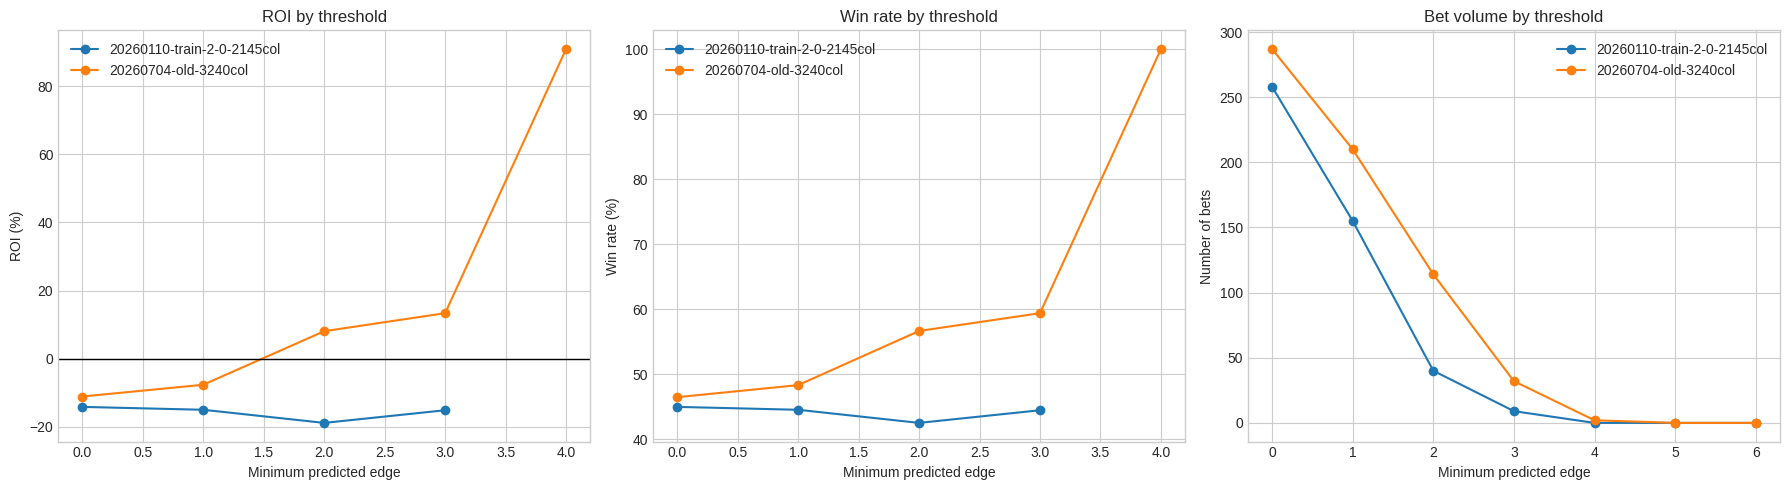

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for row in selected_runs.itertuples(index=False):
    sweep_path = EXPERIMENT_ROOT / row.run_name / "betting_sweep.csv"
    if not sweep_path.exists():
        continue
    sweep = pd.read_csv(sweep_path)
    label = str(row.comparison_key)
    axes[0].plot(sweep["min_edge"], sweep["roi"] * 100, marker="o", label=label)
    axes[1].plot(sweep["min_edge"], sweep["win_rate"] * 100, marker="o", label=label)
    axes[2].plot(sweep["min_edge"], sweep["n_bets"], marker="o", label=label)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("ROI by threshold")
axes[0].set_ylabel("ROI (%)")
axes[1].set_title("Win rate by threshold")
axes[1].set_ylabel("Win rate (%)")
axes[2].set_title("Bet volume by threshold")
axes[2].set_ylabel("Number of bets")
for ax in axes:
    ax.set_xlabel("Minimum predicted edge")
    ax.legend()
plt.tight_layout()
plt.show()

## 8. Optuna search behaviour

Whether the search improved with more trials, and whether one run completed materially fewer trials because of its timeout — an unfair tuning comparison is a common reason two configurations look different when they are not.

Trials are selected lexicographically (best MAE within tolerance, then best OU accuracy), so the lowest-MAE trial is not necessarily the one used.

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))
trial_summaries = []
for row in selected_runs.itertuples(index=False):
    trials_path = EXPERIMENT_ROOT / row.run_name / "optuna_trials.csv"
    if not trials_path.exists():
        continue
    trials = pd.read_csv(trials_path).sort_values("trial")
    trials["best_mae_so_far"] = trials["value_mae"].cummin()
    label = str(row.comparison_key)
    ax.plot(trials["trial"], trials["best_mae_so_far"], marker=".", label=label)
    trial_summaries.append({
        "comparison_key": label,
        "completed_trials": len(trials),
        "best_cv_mae": trials["value_mae"].min(),
    })
ax.set_xlabel("Trial number")
ax.set_ylabel("Best CV MAE so far")
ax.set_title("Optuna convergence")
ax.legend()
plt.tight_layout()
plt.show()
display(pd.DataFrame(trial_summaries).style.format({"best_cv_mae": "{:.4f}"}))

## 9. Prediction residuals

Residual timelines reveal a model that fails during a particular stretch of its holdout. Runs on different holdout periods are plotted descriptively — they are not paired predictions and should not be read as a head-to-head.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for row in selected_runs.itertuples(index=False):
    predictions_path = EXPERIMENT_ROOT / row.run_name / "final_test_predictions.parquet"
    if not predictions_path.exists():
        continue
    predictions = pd.read_parquet(predictions_path).copy()
    predictions["GAME_DATE"] = pd.to_datetime(predictions["GAME_DATE"])
    predictions = predictions.sort_values("GAME_DATE").reset_index(drop=True)
    predictions["residual"] = predictions["y_true"] - predictions["y_pred"]
    predictions["rolling_residual"] = predictions["residual"].rolling(25, min_periods=8).mean()
    label = str(row.comparison_key)
    axes[0].plot(predictions["GAME_DATE"], predictions["rolling_residual"], label=label)
    axes[1].hist(predictions["residual"].dropna(), bins=25, alpha=0.45, label=label)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Rolling mean residual (25 games)")
axes[0].set_ylabel("Actual − predicted points")
axes[0].set_xlabel("Game date")
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Residual distribution")
axes[1].set_xlabel("Actual − predicted points")
axes[1].set_ylabel("Games")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

## Interpretation checklist

In rough order of how often each one invalidates a conclusion:

1. **Same evaluation cohort?** (§2) Different holdout dates means the baselines differ too, and MAE/ROI are not comparable.
2. **Only one thing changed?** (§6) More than one substantive config difference and no outcome can be attributed to any of them.
3. **Is the CV edge consistent?** (§4) Mean edge over fold-to-fold spread matters more than the headline `cv_mae`. An edge carried by two folds out of ten is not an edge.
4. **Does CV agree with the test set?** (§3) They usually should. A large gap is normally the small test sample, not a regime change.
5. **Does it beat the *line*, not just the other model?** Both `baseline_holdout_mae` and the harder `bias_baseline_roi`.
6. **Is the ROI backed by volume and a credible interval?** A win-rate CI crossing break-even means "not proven", regardless of the point estimate.
7. **Is the profit steady or one lucky week?** (§5) The cumulative curve, not the average.
8. **Is a "significant" threshold real?** (§7) With 7 thresholds you expect ~1 false positive at 95%.
9. **Was tuning fair?** (§8) Similar completed trial counts.

Record the conclusion in the experiment's `hypothesis` field or the campaign README — not in the plots, which get regenerated.